# Filtering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import scipy.signal as sig
import skimage.io as io
import skimage.data as data
import skimage.transform as transform
import skimage.color as color
import skimage.filters as filters
from skimage.util import img_as_float
from numpy import log, absolute, angle
from scipy.fft import fft2, fftshift, ifft2, ifftshift

import matplotlib as mpl
plt.style.use('../_static/bip.mplstyle')
mpl.rcParams['xtick.bottom'] = False
mpl.rcParams['ytick.left'] = False
plt.rcParams['image.cmap'] = 'gray'

## Examples of image convolution

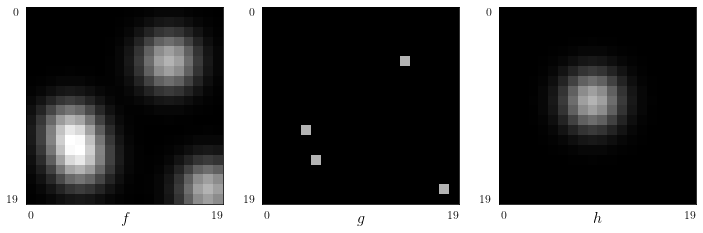

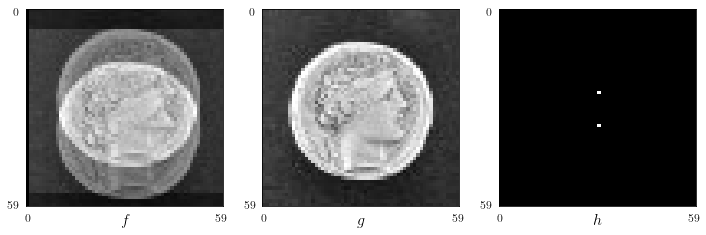

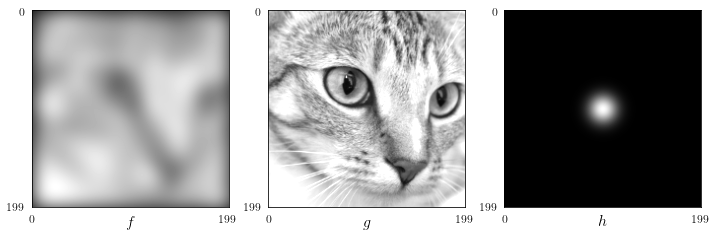

In [2]:
def image(ax, img, lbl, vmax):
    ax.imshow(img, vmin=0, vmax=vmax)
    ax.set_xlabel(lbl, labelpad=-10)
    ax.set_xticks([0, img.shape[1]-1])
    ax.set_yticks([0, img.shape[0]-1])

# Initialisation de l'affichage

# N = 3 # Nombre d'images
# fig, axs = plt.subplots(N,3, figsize=(12, 4*N))

# Diracs

g = np.zeros((20,20))
g[15, 5] = 1
g[12, 4] = 1
g[5, 14] = 1
g[18, 18] = 1
d = np.zeros((20, 20))
d[9, 9] = 1
h = ndi.gaussian_filter(d, sigma=2)
h = h / h.max()
f = sig.convolve2d(g, h, mode='same')
fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=f.max())
plt.savefig("conv-example1.svg")

# ...

g = data.coins()
g = g[165:225, 72:132]
sigma = 7
h = np.zeros((60,60))
h[25, 30] = 1
h[35, 30] = 1
h = h/np.sum(np.sum(h))
f = sig.convolve2d(g, h, mode='same')
fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=h.max())
plt.savefig("conv-example2.svg")

# Blur

g = color.rgb2gray( data.cat() )
g = g[:,50:350]
g = transform.resize(g, (200, 200))
d = np.zeros((200,200))
d[100, 100] = 1
h = ndi.gaussian_filter(d, sigma=10)
h = h/np.sum(np.sum(h))
f = sig.convolve2d(g, h, mode='same')
fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=h.max())
plt.savefig("conv-example3.svg")

## Boundaries effects

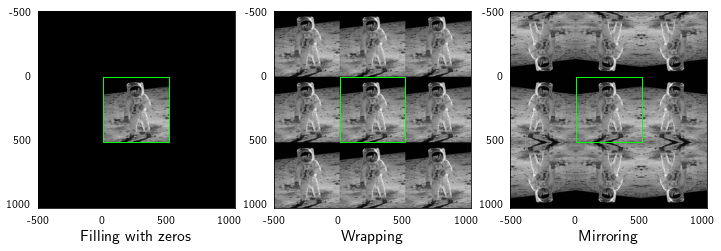

In [14]:
# Image to convolve
img = io.imread("../_static/figs/aldrin.png")
img = color.rgb2gray(img)
N = img.shape[0]

# Fill with 0
img_zeros = np.zeros((3*N, 3*N))
img_zeros[N:2*N, N:2*N] = img

# Wrap (periodic or circular condition)
img_wrap = np.zeros((3*N, 3*N))
for x in range(3):
    for y in range(3):
        img_wrap[x*N:(x+1)*N, y*N:(y+1)*N] = img

# Mirror (symmetrical condition)
img_symm = np.zeros((3*N, 3*N))
for x in range(3):
    for y in range(3):
        xdir = -1 if (x%2) == 0 else 1
        ydir = -1 if (y%2) == 0 else 1
        img_symm[x*N:(x+1)*N, y*N:(y+1)*N] = img[::xdir,::ydir]

def image(ax, img, label):
    N = 500
    ax.imshow(img, cmap="gray")
    ax.set_xlabel(label)
    ax.set_xticks(np.arange(0, 3*N+1, N))linspace
    ax.set_xticklabels(np.arange(-N, 2*N+1, N))
    ax.set_yticks(np.arange(0, 3*N+1, N))
    ax.set_yticklabels(np.arange(-N, 2*N+1, N))
    
# Display
fig, axs = plt.subplots(1,3, figsize=(12,4))
image(axs[0], img_zeros, "Filling with zeros")
axs[0].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)
image(axs[1], img_wrap, "Wrapping")
axs[1].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)
image(axs[2], img_symm, "Mirroring")
axs[2].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)

plt.savefig("boundaries-hypotheses.svg")

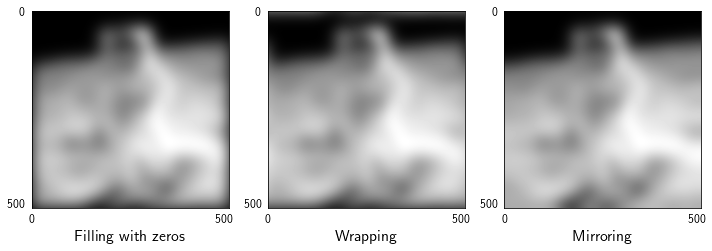

In [4]:
# Convolution of the previous images by a Gaussian PSF
sigma = 20
img_zeros = filters.gaussian(img, sigma=sigma, mode='constant', cval=0)
img_wrap = filters.gaussian(img, sigma=sigma, mode='wrap')
img_symm = filters.gaussian(img, sigma=sigma, mode='mirror')

def image(ax, img, label):
    N = 500
    ax.imshow(img, cmap="gray")
    ax.set_xlabel(label)
    ax.set_xticks(np.arange(0, N+1, N))
    ax.set_xticklabels(np.arange(0, N+1, N))
    ax.set_yticks(np.arange(0, N+1, N))
    ax.set_yticklabels(np.arange(0, N+1, N))

# Display
fig, axs = plt.subplots(1,3, figsize=(12,4))
image(axs[0], img_zeros, "Filling with zeros")
image(axs[1], img_wrap, "Wrapping")
image(axs[2], img_symm, "Mirroring")

plt.savefig("boundaries-results.svg")

# Fourier transform

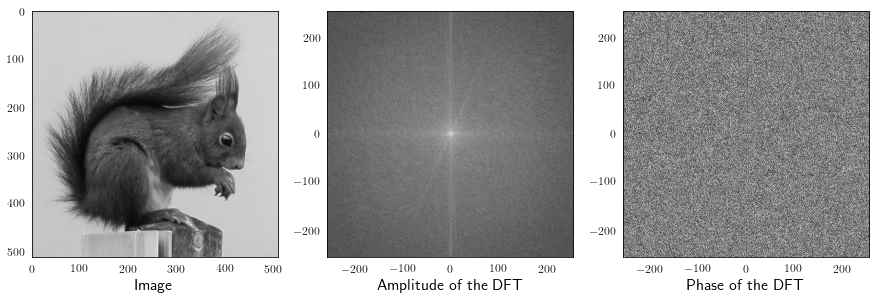

In [5]:
f = io.imread("../figs/squirrel.png")
(M, N) = f.shape
F = fftshift(fft2(f))

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(f, cmap="gray")
axs[0].set_xlabel("Image")
axs[1].imshow(log(absolute(F)), cmap="gray", extent = [-M/2 , M/2, -N/2, N/2])
axs[1].set_xlabel("Amplitude of the DFT")
axs[2].imshow(angle(F), cmap="gray", extent = [-M/2 , M/2, -N/2, N/2])
axs[2].set_xlabel("Phase of the DFT")

plt.savefig("fourier-example.svg")

## Filtering

In [7]:
# Original image & DFT
g = io.imread("../figs/squirrel.png")
(M,N) = g.shape
G = fftshift(fft2(g))
N = g.shape[0]

# Filter
n = np.linspace(0, N, N)
xx, yy = np.meshgrid(n, n)

In [25]:
# Display images
def display(img, name, vmin=None, vmax=None, spatial=True):
    all_axes = plt.gcf().get_axes()
    plt.subplot(2,3,len(all_axes)+1)
    if vmin==None:
        vmin = img.min()
    if vmax==None:
        vmax = img.max()
    if spatial:
        plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    else:
        plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, extent = [-M/2 , M/2, -N/2, N/2])
    plt.xlabel(name)

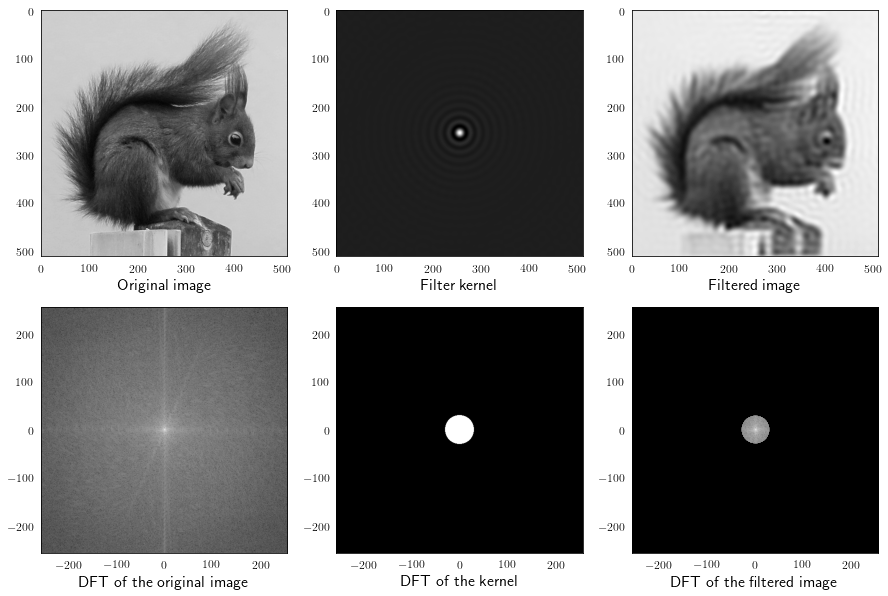

In [27]:
# Low-pass
H = ((xx-N/2)**2 + (yy-N/2)**2 < 30**2)
H = img_as_float(H)
h = np.real(ifft2(ifftshift(H)))
h = fftshift(h) # Pour centrer la PSF

# Filtered image & DFT
F = G*H
f = np.real(ifft2(ifftshift(F)))

fig = plt.figure(figsize=(15,10))

display(g, "Original image")
display(h, "Filter kernel")
display(f, "Filtered image")

laG = log(abs(G))
vmin, vmax = laG.min(), laG.max()
display(np.log(abs(G)), "DFT of the original image", vmin=vmin, vmax=vmax, spatial=False)
display(np.log(abs(H + 1e-9)), "DFT of the kernel", spatial=False)
display(np.log(abs(F + 1e-9)), "DFT of the filtered image", vmin=vmin, vmax=vmax, spatial=False)

plt.savefig("lowpass.svg")

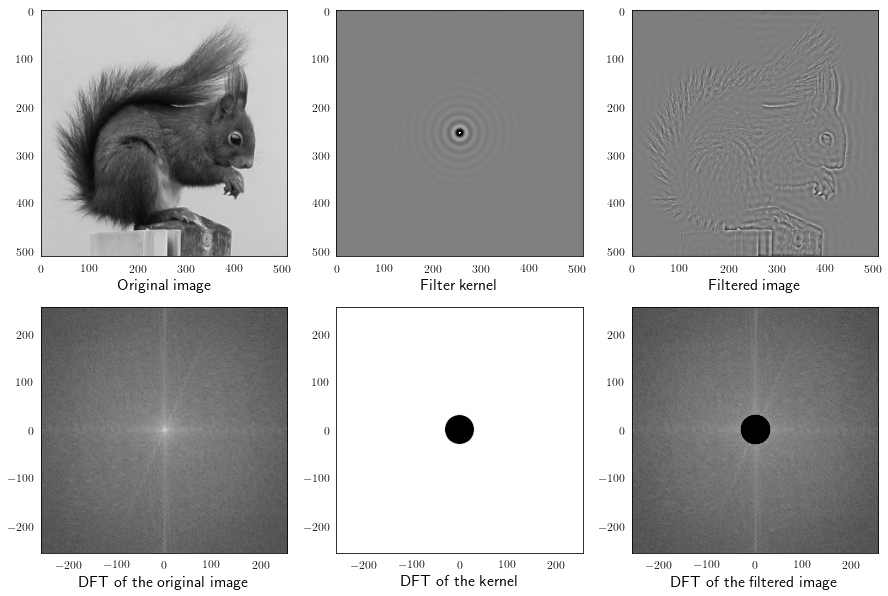

In [64]:
# High-pass

H = ((xx-N/2)**2 + (yy-N/2)**2 > 30**2)
H = img_as_float(H)
h = np.real(ifft2(ifftshift(H)))
h = fftshift(h) # Pour centrer la PSF

# Filtered image & DFT
F = G*H
f = np.real(ifft2(ifftshift(F)))

fig = plt.figure(figsize=(15,10))
display(g, "Original image")
display(h, "Filter kernel", vmin=-5e-3, vmax=5e-3)
display(f, "Filtered image")

laG = log(abs(G))
vmin, vmax = laG.min(), laG.max()
display(np.log(abs(G)), "DFT of the original image", vmin=vmin, vmax=vmax, spatial=False)
display(np.log(abs(H + 1e-9)), "DFT of the kernel", spatial=False)
display(np.log(abs(F + 1e-9)), "DFT of the filtered image", vmin=vmin, vmax=vmax, spatial=False)

plt.savefig("highpass.svg")